In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"../../../../output/age_depth_unified_cap/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified_cap/energy_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified_cap/bias_{config_str}.npy")
# resampled_samples = np.load(f"../../../../output/age_depth_unified_cap/resamp_{config_str}.npy")

In [4]:
# print(np.shape(resampled_samples))
print(np.shape(samples))

(4, 1000, 50)


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
print(energy_values)

[[154.4379893  144.42825987 151.85788837 ... 113.23887431 109.16960071
  115.61440812]
 [169.01557468 151.0655144  148.01654862 ...  96.02311483 100.27457288
  104.68617751]
 [192.38527107 179.88682148 172.96842704 ... 112.94708201 101.29386567
  100.43675706]
 [207.19405117 178.77108663 170.13307494 ... 129.13223314 131.24062819
  128.53112009]]


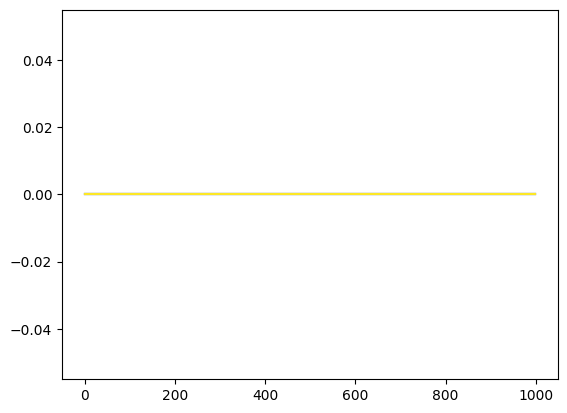

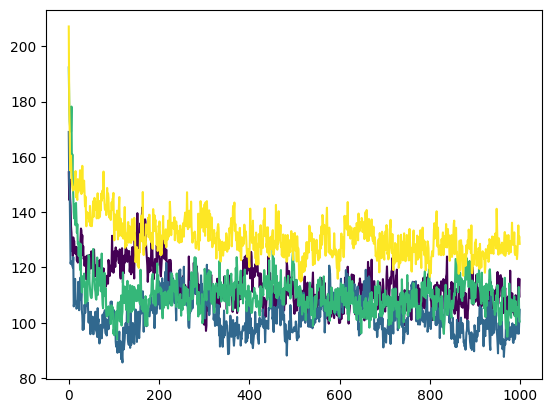

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


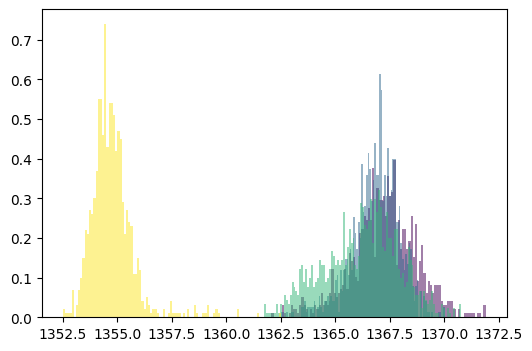

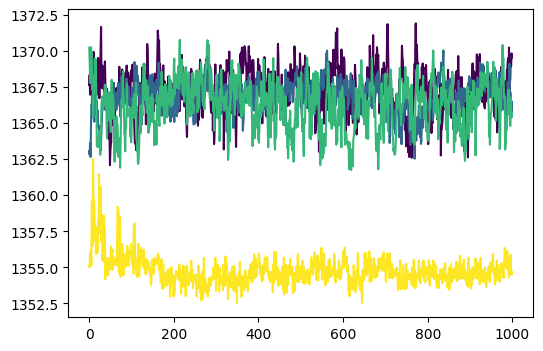

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
# samples = samples[:,::100,:]

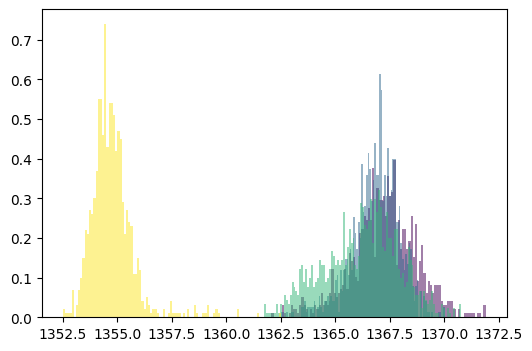

In [10]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

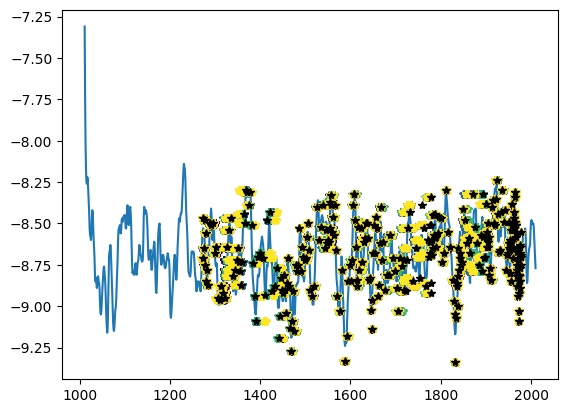

In [11]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [12]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.80  0.23    2.37     3.23       0.02     0.01    197.12    589.73   
x[1]    4.58  0.53    3.56     5.51       0.05     0.02    129.99    437.59   
x[2]    5.80  0.72    4.41     7.06       0.07     0.02    124.76    376.26   
x[3]    6.19  0.81    4.73     7.79       0.07     0.05    126.67    208.84   
x[4]    6.98  0.83    5.25     8.45       0.08     0.09    123.26    161.73   
x[5]    4.67  0.90    2.86     6.23       0.18     0.09     27.72     46.99   
x[6]    4.30  1.18    2.33     6.50       0.21     0.16     37.77     31.38   
x[7]    3.45  1.08    1.59     5.41       0.19     0.10     32.49     75.62   
x[8]    5.95  2.46    1.14     9.38       1.08     0.51      6.38     12.03   
x[9]    9.54  3.05    3.32    14.36       1.33     0.58      5.56     20.42   
x[10]   4.59  2.13    0.47     7.93       0.90     0.40      6.48     14.75   
x[11]   5.68  3.72    0.79    12.31       1.80     0

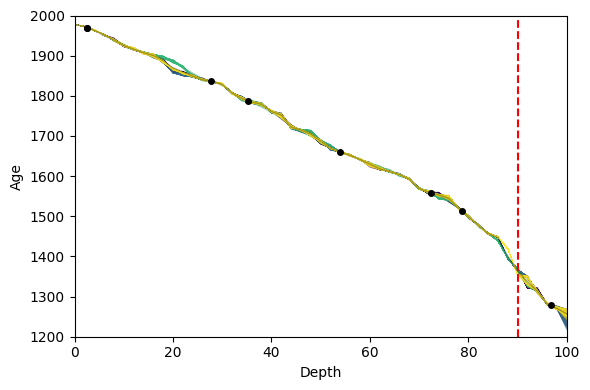

In [13]:
cumulative_sums = np.cumsum(samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        pass
        # ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()